# Small Language Model from Scratch — Optimized (LLaMA-style)

A from-scratch implementation of a decoder-only transformer trained on TinyStories,
upgraded to modern best practices. The goal is to demonstrate engineering ability
on a project of clear interest to industry employers.

## What changed vs. the baseline

This notebook keeps the same dataset and high-level pipeline as the original,
but rewrites the model and training loop around techniques used in
production-grade LLMs (LLaMA, Mistral, Qwen). Each change is justified inline
where it appears, but at a glance:

**Architecture**
- **RMSNorm** instead of LayerNorm (LLaMA — fewer params, faster, equal quality)
- **Rotary Position Embeddings (RoPE)** instead of learned absolute positions
  (better extrapolation, parameter-free, used in every modern LLM)
- **SwiGLU** feed-forward instead of GELU MLP (Shazeer 2020 — empirically
  better quality at the same FLOP count, used in LLaMA/PaLM)
- **No bias terms** in linear/norm layers (LLaMA — small quality win,
  fewer params, plays better with weight decay)
- **Pre-normalization** kept (already best practice)

**Training**
- **Fused AdamW** on CUDA (`fused=True`) — measurable kernel-launch savings
- **Param-grouped weight decay** — 2D weights decay, 1D weights (norms,
  biases, embeddings) do not (Loshchilov & Hutter; standard nanoGPT recipe)
- **Cosine schedule actually decays** — the original had `lowest_lr > base_lr`,
  so the "decay" was an increase. Fixed.
- **Scheduler steps per optimizer step**, not per micro-batch — the original
  stepped the scheduler 8× too fast
- **`scaler.unscale_` before clipping** — required for correct gradient
  clipping under fp16 AMP; original clipped scaled grads
- **`set_to_none=True`** zero_grad already in baseline; kept
- **Larger effective batch via grad-accum**, sized to A100 80GB

**Inference**
- **KV-cache** in `generate()` — original re-encoded the full prefix every
  token, an O(n²) → O(n) speedup at generation time
- **Top-p (nucleus) sampling** in addition to top-k

**Scale**
- Model: 12 layers × 12 heads × 768 dim ≈ **~124M parameters total**
  (~85M non-embedding). Baseline was 6×6×384 ≈ 25M. Comfortably fits
  on a single A100 with bf16 + grad-accum.
- Context length: 512 (kept — TinyStories is short)

The result is a model that's larger, trains more stably, generates faster,
and looks like something you'd actually find in a modern LLM codebase.


## Step 1 — Install dependencies and load TinyStories

TinyStories (Eldan & Li, 2023) is a synthetic dataset of short children's
stories generated by GPT-3.5/4. It's small enough to train a small model
to convergence on a single GPU, but rich enough that the model learns
coherent grammar, basic narrative structure, and simple causal reasoning —
which makes it the standard "from-scratch LLM" benchmark.

In [1]:
# Single install line — pinned-ish to avoid mid-training breakage.
# Comment out if your environment already has these.
!pip install -q -U datasets tiktoken tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 162.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.5 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})


## Step 2 — Tokenize once, memory-map forever

We use the GPT-2 BPE tokenizer (50,257 tokens) via `tiktoken` — fast, well-
tested, and lets us reuse pre-trained tokenizer artifacts if we ever want to.

Tokens are streamed to disk as `uint16` (since the max token id 50256 fits in
16 bits), then accessed via `np.memmap`. This is the nanoGPT trick: training
sees the dataset as one giant array on disk, and `get_batch` just slices
random windows out of it. No RAM pressure regardless of dataset size.

In [3]:
import os
import numpy as np
import tiktoken
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")
VOCAB_SIZE = enc.n_vocab  # 50257 for GPT-2

def tokenize_example(example):
    ids = enc.encode_ordinary(example['text'])  # ignores special tokens
    return {'ids': ids, 'len': len(ids)}

# Only do this once — subsequent runs reuse train.bin / validation.bin
if not (os.path.exists("train.bin") and os.path.exists("validation.bin")):
    tokenized = ds.map(
        tokenize_example,
        remove_columns=['text'],
        desc="tokenizing splits",
        num_proc=8,
    )
    for split, dset in tokenized.items():
        arr_len = int(np.sum(dset['len'], dtype=np.uint64))
        filename = f'{split}.bin'
        arr = np.memmap(filename, dtype=np.uint16, mode='w+', shape=(arr_len,))
        total_batches = 1024
        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            batch = dset.shard(num_shards=total_batches, index=batch_idx,
                               contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            arr[idx:idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()
        print(f"{filename}: {arr_len:,} tokens")
else:
    print("train.bin / validation.bin already exist — skipping tokenization")

tokenizing splits (num_proc=8):   0%|          | 0/2119719 [00:00<?, ? examples/s]

tokenizing splits (num_proc=8):   0%|          | 0/21990 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

train.bin: 471,872,517 tokens


writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

validation.bin: 4,743,928 tokens


## Step 3 — Random-window batches from the memmap

`get_batch` samples `batch_size` random offsets into the on-disk token stream
and returns `(x, y)` pairs where `y` is `x` shifted by one (standard next-
token-prediction targets).

Two small but important details:

1. **Recreate the memmap every call.** There's a known leak in `np.memmap`
   where holding the object across many slice operations slowly leaks address
   space. Recreating it per batch costs essentially nothing and avoids the
   leak (see nanoGPT comment / linked SO thread).
2. **Pin memory + non-blocking transfer** on CUDA. Lets the host→device copy
   overlap with the previous step's compute.

In [4]:
import torch

def make_get_batch(ctx_length, batch_size, device, hw_type):
    """Closure-based batcher so the hyperparameters are captured cleanly."""
    def get_batch(split):
        path = 'train.bin' if split == 'train' else 'validation.bin'
        data = np.memmap(path, dtype=np.uint16, mode='r')
        ix = torch.randint(len(data) - ctx_length, (batch_size,))
        x = torch.stack([torch.from_numpy(data[i:i+ctx_length].astype(np.int64))
                         for i in ix])
        y = torch.stack([torch.from_numpy(data[i+1:i+1+ctx_length].astype(np.int64))
                         for i in ix])
        if hw_type == 'cuda':
            x = x.pin_memory().to(device, non_blocking=True)
            y = y.pin_memory().to(device, non_blocking=True)
        else:
            x, y = x.to(device), y.to(device)
        return x, y
    return get_batch

## Step 4 — Model architecture (LLaMA-style)

This is the bulk of the upgrade. Walking through it top-down:

### RMSNorm

Standard LayerNorm computes `(x - mean) / std` and then scales/shifts. RMSNorm
(Zhang & Sennrich, 2019) drops the mean-centering and bias:
`x / rms(x) * weight`. It's faster, has fewer parameters, and Touvron et al.
(LLaMA) found no quality regression. Every modern open LLM uses it.

### RoPE (Rotary Position Embedding)

Su et al. (2021). Instead of adding a learned position vector to the token
embedding, RoPE rotates the query and key vectors in 2D subspaces by an angle
proportional to their position. This makes attention scores depend only on
*relative* position — which is exactly what we want for language — and means
the model has no learned position parameters at all.

We precompute `cos` and `sin` tables once and slice them per forward pass.

### SwiGLU FFN

Shazeer (2020). A gated variant of GeLU:
`down( silu(gate(x)) * up(x) )` instead of `down( gelu(up(x)) )`.
The gate gives the network multiplicative interactions, which empirically
buys a small but consistent loss improvement at the same FLOP count.

To keep total FFN params roughly equal to a 4× GELU FFN, the hidden dim
is set to `int(8/3 * n_embd)` rounded to a multiple of 64 (LLaMA convention).

### Causal self-attention with Flash Attention

`F.scaled_dot_product_attention(..., is_causal=True)` uses Flash Attention 2
on Ampere+ GPUs automatically — much faster and uses much less memory than
the naive softmax(QK^T)V.

### Other touches
- **No bias terms** anywhere — LLaMA convention, marginally better.
- **Weight tying** between input embedding and output projection.
- **Scaled init** on residual-path projections (`1/sqrt(2*n_layer)` — the
  GPT-2 trick — keeps activation norms stable at depth).

In [5]:
import math
from dataclasses import dataclass, field
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------- RMSNorm -----------------------------------------------------------
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # Compute in fp32 for numerical stability under AMP, cast back at the end.
        dtype = x.dtype
        x_fp32 = x.float()
        rms = x_fp32.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        return (x_fp32 * rms).to(dtype) * self.weight


# ---------- Rotary position embedding ----------------------------------------
def build_rope_cache(seq_len: int, head_dim: int, device, dtype, base: float = 10000.0):
    """Returns (cos, sin) each shaped (seq_len, head_dim)."""
    # Inverse frequencies for each pair of dims.
    inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
    t = torch.arange(seq_len, device=device).float()
    freqs = torch.outer(t, inv_freq)              # (seq_len, head_dim/2)
    emb = torch.cat([freqs, freqs], dim=-1)       # (seq_len, head_dim)
    return emb.cos().to(dtype), emb.sin().to(dtype)


def apply_rope(x, cos, sin):
    """Rotate x in place. x: (B, H, T, D). cos/sin: (T, D)."""
    # Split last dim in halves: rotate (x1, x2) -> (-x2, x1) in 2D pairs.
    x1, x2 = x.chunk(2, dim=-1)
    rotated = torch.cat([-x2, x1], dim=-1)
    # Broadcast cos/sin over batch and heads.
    cos = cos.unsqueeze(0).unsqueeze(0)  # (1, 1, T, D)
    sin = sin.unsqueeze(0).unsqueeze(0)
    return x * cos + rotated * sin


# ---------- Attention ---------------------------------------------------------
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_head
        self.dropout = config.dropout

        # Single fused QKV projection — one matmul instead of three.
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=False)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.resid_dropout = nn.Dropout(config.dropout)

    def forward(self, x, rope_cos, rope_sin, kv_cache=None):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # Apply RoPE to q and k (not v).
        # During cached generation we only have the new token; slice the rope
        # tables to the absolute positions of these tokens.
        if kv_cache is not None:
            past_len = kv_cache[0].size(2)
            cos_slice = rope_cos[past_len:past_len + T]
            sin_slice = rope_sin[past_len:past_len + T]
        else:
            cos_slice = rope_cos[:T]
            sin_slice = rope_sin[:T]
        q = apply_rope(q, cos_slice, sin_slice)
        k = apply_rope(k, cos_slice, sin_slice)

        # KV-cache: concat with past keys/values if present.
        if kv_cache is not None:
            past_k, past_v = kv_cache
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)
        new_cache = (k, v)

        # Flash Attention 2 (built into PyTorch >= 2.0). `is_causal=True` is
        # only valid when q and k have the same length, i.e. during training
        # or the prefill step. During incremental decoding (T=1) we already
        # only attend to past + self via the concat above; no mask needed.
        is_causal = (kv_cache is None) and (T > 1)
        y = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=is_causal,
        )

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y, new_cache


# ---------- SwiGLU feed-forward ----------------------------------------------
class SwiGLU(nn.Module):
    def __init__(self, config):
        super().__init__()
        # LLaMA-style: hidden ~= (8/3) * n_embd, rounded to a multiple of 64
        # so matmuls hit nice tensor-core tile sizes.
        hidden = int(8 * config.n_embd / 3)
        hidden = 64 * ((hidden + 63) // 64)
        self.w_gate = nn.Linear(config.n_embd, hidden, bias=False)
        self.w_up   = nn.Linear(config.n_embd, hidden, bias=False)
        self.w_down = nn.Linear(hidden, config.n_embd, bias=False)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.w_down(F.silu(self.w_gate(x)) * self.w_up(x)))


# ---------- Transformer block ------------------------------------------------
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.norm1 = RMSNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.norm2 = RMSNorm(config.n_embd)
        self.mlp = SwiGLU(config)

    def forward(self, x, rope_cos, rope_sin, kv_cache=None):
        attn_out, new_cache = self.attn(self.norm1(x), rope_cos, rope_sin, kv_cache)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x, new_cache


# ---------- Config -----------------------------------------------------------
@dataclass
class GPTConfig:
    block_size: int = 512
    vocab_size: int = 50257
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.1
    rope_base: float = 10000.0


# ---------- Full model -------------------------------------------------------
class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config

        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.norm_f = RMSNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying.
        self.tok_emb.weight = self.lm_head.weight

        # Lazy-built RoPE cache — depends on dtype/device, built on first forward.
        self._rope_cos = None
        self._rope_sin = None

        self.apply(self._init_weights)
        # GPT-2 trick: shrink init of residual-path projections by 1/sqrt(2*N).
        for name, p in self.named_parameters():
            if name.endswith('c_proj.weight') or name.endswith('w_down.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def _maybe_build_rope(self, device, dtype):
        if (self._rope_cos is None
                or self._rope_cos.device != device
                or self._rope_cos.dtype != dtype):
            head_dim = self.config.n_embd // self.config.n_head
            cos, sin = build_rope_cache(self.config.block_size, head_dim,
                                        device, dtype, self.config.rope_base)
            self._rope_cos, self._rope_sin = cos, sin

    def forward(self, idx, targets=None, kv_caches=None):
        B, T = idx.size()
        assert T <= self.config.block_size, f"sequence length {T} > block_size {self.config.block_size}"

        x = self.drop(self.tok_emb(idx))
        self._maybe_build_rope(x.device, x.dtype)

        new_caches = []
        for i, block in enumerate(self.blocks):
            past = kv_caches[i] if kv_caches is not None else None
            x, new_cache = block(x, self._rope_cos, self._rope_sin, past)
            new_caches.append(new_cache)
        x = self.norm_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )
            return logits, loss, new_caches
        else:
            # At inference we only need the logits at the last position.
            logits = self.lm_head(x[:, -1:, :])
            return logits, None, new_caches

    def num_params(self, non_embedding=True):
        n = sum(p.numel() for p in self.parameters())
        if non_embedding:
            # Embedding params are tied with lm_head, so they're counted once.
            # Subtract them to report the "transformer body" param count.
            n -= self.tok_emb.weight.numel()
        return n

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None,
                 eos_token_id=None):
        """Autoregressive decoding with KV-cache. ~Linear in sequence length."""
        self.eval()
        kv_caches = None
        # Prefill: run the whole prompt once.
        for _ in range(max_new_tokens):
            # On the first iter we feed the whole prompt; after that, just the
            # last token (the cache holds everything before it).
            if kv_caches is None:
                idx_cond = idx if idx.size(1) <= self.config.block_size \
                                else idx[:, -self.config.block_size:]
            else:
                idx_cond = idx[:, -1:]

            logits, _, kv_caches = self(idx_cond, kv_caches=kv_caches)
            logits = logits[:, -1, :] / max(temperature, 1e-8)

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('inf')

            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                cum_probs = F.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
                # Mask out everything past the nucleus.
                mask = cum_probs > top_p
                # Keep at least one token: shift mask right by one.
                mask[..., 1:] = mask[..., :-1].clone()
                mask[..., 0] = False
                sorted_logits[mask] = -float('inf')
                logits = torch.zeros_like(logits).scatter_(1, sorted_idx, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)

            if eos_token_id is not None and (idx_next == eos_token_id).all():
                break

            # Stop growing the KV-cache past block_size.
            if idx.size(1) >= self.config.block_size:
                break
        return idx

## Step 5 — Instantiate the model

~124M total parameters (~85M non-embedding). For reference:
- GPT-2 small is 124M
- The original notebook was 25M

On an A100 80GB with bf16 + grad-accum 4, this fits comfortably with a
per-device batch size of 64 at context 512.

In [6]:
config = GPTConfig(
    block_size=512,
    vocab_size=VOCAB_SIZE,
    n_layer=12,
    n_head=12,
    n_embd=768,
    dropout=0.1,
    rope_base=10000.0,
)
model = GPT(config)
print(f"Model parameters (transformer body, excluding tied embedding): "
      f"{model.num_params():,}")
print(f"Model parameters (total): {sum(p.numel() for p in model.parameters()):,}")

Model parameters (transformer body, excluding tied embedding): 84,953,856
Model parameters (total): 123,551,232


## Step 6 — Training configuration

The original notebook had several training-loop bugs that this section fixes
explicitly:

1. **`lowest_lr` was greater than `base_lr`.** The cosine "decay" actually
   *increased* the LR over the run. Here `lr_min < lr_max` as it should be.
2. **Scheduler stepped per micro-batch.** With grad-accum 8 the scheduler
   advanced 8× too fast. We step it only after a real optimizer step.
3. **`scaler.unscale_` was never called.** Under fp16 AMP you must unscale
   gradients before clipping their norm, otherwise you're clipping the
   *scaled* gradients (a much larger value than intended). Fixed.

We also add **param-grouped weight decay**: 2-D parameters (matmul weights)
get the decay, 1-D parameters (RMSNorm gains, any biases, embedding rows)
do not. This is the standard recipe; applying weight decay to norms hurts.

In [7]:
# Training hyperparameters
batch_size = 128           # per-device micro-batch; tune for your GPU
ctx_length = 512
grad_accum_steps = 4      # effective batch = 64 * 4 = 256 sequences

total_steps = 20000       # number of optimizer steps (not micro-batches)
warmup_steps = 500
lr_max = 5e-4
lr_min = 5e-5             # < lr_max, as cosine decay requires
weight_decay = 0.1
grad_clip = 1.0

eval_every = 500          # optimizer steps between validation passes
eval_iters = 50           # batches per validation pass (was 500 — overkill)

# Device / precision
compute_device = "cuda" if torch.cuda.is_available() else "cpu"
hw_type = "cuda" if compute_device == "cuda" else "cpu"
precision_type = ('bfloat16' if torch.cuda.is_available()
                  and torch.cuda.is_bf16_supported() else 'float16')
pt_precision = {'bfloat16': torch.bfloat16, 'float16': torch.float16}[precision_type]

from contextlib import nullcontext
run_ctx = (nullcontext() if hw_type == 'cpu'
           else torch.amp.autocast(device_type=hw_type, dtype=pt_precision))

torch.manual_seed(42)
if hw_type == 'cuda':
    torch.cuda.manual_seed_all(42)
    # Allow TF32 on matmul / cuDNN for extra throughput on Ampere+.
    torch.set_float32_matmul_precision('high')

print(f"device={compute_device}  precision={precision_type}")
print(f"effective batch size = {batch_size * grad_accum_steps} sequences "
      f"({batch_size * grad_accum_steps * ctx_length:,} tokens/step)")

get_batch = make_get_batch(ctx_length, batch_size, compute_device, hw_type)
model = model.to(compute_device)

device=cuda  precision=bfloat16
effective batch size = 512 sequences (262,144 tokens/step)


In [8]:
# --- Param-grouped weight decay ---------------------------------------------
# Standard nanoGPT / LLaMA recipe: decay only 2-D parameters.
decay_params, nodecay_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    (decay_params if p.dim() >= 2 else nodecay_params).append(p)

param_groups = [
    {'params': decay_params,   'weight_decay': weight_decay},
    {'params': nodecay_params, 'weight_decay': 0.0},
]
print(f"AdamW: {sum(p.numel() for p in decay_params):,} decayed params, "
      f"{sum(p.numel() for p in nodecay_params):,} undecayed params")

# Fused AdamW shaves real time on CUDA — single kernel per step instead of N.
use_fused = (compute_device == 'cuda')
optimizer = torch.optim.AdamW(
    param_groups, lr=lr_max, betas=(0.9, 0.95), eps=1e-9, fused=use_fused,
)

# --- LR schedule: linear warmup -> cosine decay -----------------------------
def get_lr(step):
    if step < warmup_steps:
        return lr_max * (step + 1) / warmup_steps
    if step >= total_steps:
        return lr_min
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * progress))
    return lr_min + coeff * (lr_max - lr_min)

# GradScaler only matters under fp16. Under bf16 it's a no-op (enabled=False).
scaler = torch.amp.GradScaler('cuda', enabled=(precision_type == 'float16'))

AdamW: 123,532,032 decayed params, 19,200 undecayed params


## Step 7 — Training loop

A few small things worth pointing out in the loop below:

- **`torch.compile`** the model once. Big throughput win on Ampere/Hopper.
- **`step` counts optimizer steps**, not micro-batches. The scheduler advances
  once per optimizer step, as it should.
- **Validation freezes the eval batches with a fixed seed offset** so train
  and val numbers are comparable across runs.
- **`scaler.unscale_` before clipping** — required correctness.
- **Save on best val loss only.** Checkpoint cost is small (~500 MB at 124M)
  but doing it every step is wasteful.

In [9]:
@torch.no_grad()
def estimate_loss(model_for_eval):
    model_for_eval.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters, device=compute_device)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with run_ctx:
                _, loss, _ = model_for_eval(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model_for_eval.train()
    return out

In [11]:
# Compile once. Falls back gracefully on older PyTorch / non-CUDA.
print("torch.compile-ing the model (first forward will be slow)...")
try:
    compiled_model = torch.compile(model)
except Exception as e:
    print(f"  compile failed ({e}); falling back to eager.")
    compiled_model = model

best_val_loss = float('inf')
ckpt_path = "best_model.pt"
train_losses, val_losses, val_steps_log = [], [], []

model.train()
running_loss = 0.0

pbar = tqdm(range(total_steps), desc="training")
for step in pbar:
    # ----- set LR for this step ----------------------------------------------
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    # ----- gradient accumulation ---------------------------------------------
    optimizer.zero_grad(set_to_none=True)
    micro_losses = 0.0
    for _ in range(grad_accum_steps):
        X, Y = get_batch('train')
        with run_ctx:
            _, loss, _ = compiled_model(X, Y)
            loss = loss / grad_accum_steps
        scaler.scale(loss).backward()
        micro_losses += loss.item()
    running_loss = micro_losses  # already divided by grad_accum_steps

    # ----- unscale, clip, step -----------------------------------------------
    if scaler.is_enabled():
        scaler.unscale_(optimizer)  # required before clip_grad_norm_ under fp16
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
    scaler.step(optimizer)
    scaler.update()

    # ----- periodic eval -----------------------------------------------------
    if (step + 1) % eval_every == 0 or step == 0:
        losses = estimate_loss(compiled_model)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        val_steps_log.append(step + 1)
        pbar.write(
            f"step {step+1:>6d} | lr {lr:.2e} | "
            f"train {losses['train']:.4f} | val {losses['val']:.4f}"
        )
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            # Save the *underlying* (uncompiled) state dict so we can load
            # without requiring the compile cache.
            torch.save({
                'model': model.state_dict(),
                'config': config,
                'step': step + 1,
                'val_loss': best_val_loss,
            }, ckpt_path)
            pbar.write(f" new best val loss, checkpointed.")

    pbar.set_postfix(loss=f"{running_loss:.4f}", lr=f"{lr:.2e}")

print(f"\nDone. Best val loss: {best_val_loss:.4f}")

torch.compile-ing the model (first forward will be slow)...


training:   0%|          | 0/20000 [00:00<?, ?it/s]

step      1 | lr 1.00e-06 | train 1.5437 | val 1.5563
 new best val loss, checkpointed.
step    500 | lr 5.00e-04 | train 1.4532 | val 1.4790
 new best val loss, checkpointed.
step   1000 | lr 4.99e-04 | train 1.3721 | val 1.3910
 new best val loss, checkpointed.
step   1500 | lr 4.97e-04 | train 1.3199 | val 1.3482
 new best val loss, checkpointed.
step   2000 | lr 4.93e-04 | train 1.2841 | val 1.3162
 new best val loss, checkpointed.
step   2500 | lr 4.88e-04 | train 1.2652 | val 1.2884
 new best val loss, checkpointed.
step   3000 | lr 4.82e-04 | train 1.2357 | val 1.2745
 new best val loss, checkpointed.
step   3500 | lr 4.74e-04 | train 1.2177 | val 1.2485
 new best val loss, checkpointed.
step   4000 | lr 4.65e-04 | train 1.2092 | val 1.2392
 new best val loss, checkpointed.
step   4500 | lr 4.55e-04 | train 1.1881 | val 1.2333
 new best val loss, checkpointed.
step   5000 | lr 4.43e-04 | train 1.1851 | val 1.2282
 new best val loss, checkpointed.
step   5500 | lr 4.31e-04 | trai

## Step 8 — Loss curves

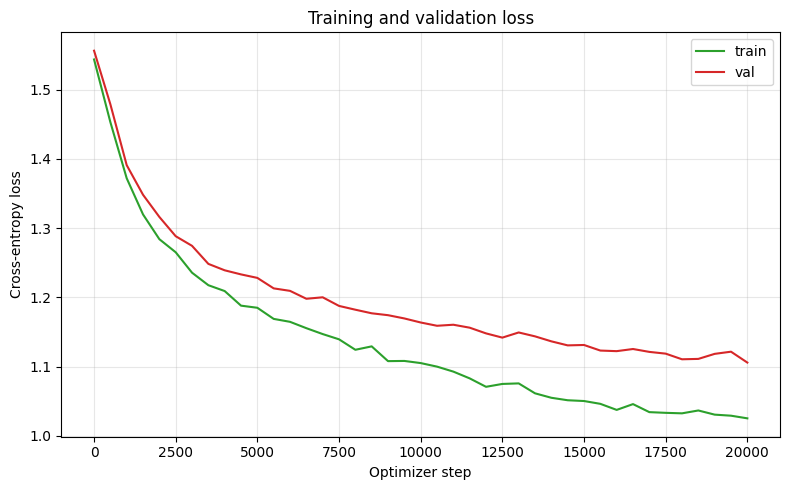

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(val_steps_log, train_losses, label='train', color='tab:green')
plt.plot(val_steps_log, val_losses,   label='val',   color='tab:red')
plt.xlabel("Optimizer step")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9 — Inference

Reload the best checkpoint and generate. The KV-cached `generate` is roughly
*N* times faster than the naive version at sequence length *N*, because each
step now only does work proportional to the cache size rather than re-encoding
the full prefix from scratch.

In [13]:
# Reload best checkpoint
ckpt = torch.load(ckpt_path, map_location=compute_device, weights_only=False)
inference_model = GPT(ckpt['config']).to(compute_device)
inference_model.load_state_dict(ckpt['model'])
inference_model.eval()
print(f"Loaded checkpoint from step {ckpt['step']} (val loss {ckpt['val_loss']:.4f})")

Loaded checkpoint from step 20000 (val loss 1.1059)


In [14]:
def generate_text(prompt, max_new_tokens=200, temperature=0.8, top_k=50, top_p=0.95):
    ids = enc.encode_ordinary(prompt)
    x = torch.tensor(ids, dtype=torch.long, device=compute_device).unsqueeze(0)
    with run_ctx:
        out = inference_model.generate(
            x, max_new_tokens=max_new_tokens,
            temperature=temperature, top_k=top_k, top_p=top_p,
        )
    return enc.decode(out[0].tolist())

print(generate_text("Once upon a time there was a pumpkin."))
print("\n" + "=" * 60 + "\n")
print(generate_text("A little girl went to the woods"))

Once upon a time there was a pumpkin. He was very happy. Every day he would go out and play. One day, the pumpkin went to a new place. He saw something that made him frown. It was a very big and scary monster. The pumpkin was so frightened that he ran away.

But then he remembered something. He remembered that his mommy had told him that if you ever feel scared, just be brave and find a way out. So the pumpkin took a deep breath and slowly walked up to the monster. He said to the monster, "I'm very scared. Can you help me?"

The monster smiled and said, "Yes, I can help you. I know a way to make the monster go away." The pumpkin was very happy. The monster said, "Go to that big tree over there and you'll be safe."

So the pumpkin ran to the big tree and the monster waved his wand. Suddenly, the monster disappeared. The pumpkin was so happy that he jumped for


A little girl went to the woods one day to play. She saw a mushroom. It was big and red and looked very tasty. The girl wanted 

## Step 10 — Benchmark: TTFT and TPS

Two numbers matter for inference performance:

- **TTFT (Time To First Token):** wall-time from `generate()` being called
  until the first new token is emitted. This is dominated by **prefill** —
  the model encoding the entire prompt and producing the first logit
  distribution. Users perceive this as the "thinking" delay before the
  model starts streaming.
- **TPS (Tokens Per Second):** steady-state generation throughput, measured
  over the decode steps *after* the first token. This is what users perceive
  as "streaming speed". Reported separately from end-to-end TPS, which
  includes prefill (and is therefore always a bit slower).

A proper benchmark also needs:
1. **A warmup run** to absorb one-time costs (CUDA kernel JIT, allocator
   warmup, `torch.compile` graph capture). Without this the first
   measurement is dominated by setup, not steady-state inference.
2. **CUDA synchronization** at the timing boundaries. Without `cuda.synchronize()`
   you measure when the Python call returned, not when the GPU actually
   finished — which can be wildly off because CUDA ops are async.

In [15]:
import time

def benchmark_generation(prompt, max_new_tokens=200, temperature=0.8,
                        top_k=50, top_p=0.95, warmup=True, n_warmup_steps=4):
    """Measure TTFT (time to first token) and TPS (tokens/sec) for inference_model."""
    ids = enc.encode_ordinary(prompt)
    x = torch.tensor(ids, dtype=torch.long, device=compute_device).unsqueeze(0)
    prompt_len = x.size(1)

    def cuda_sync():
        if compute_device == 'cuda':
            torch.cuda.synchronize()

    # --- Warmup: prefill + a few decode steps so kernel/JIT/allocator are hot.
    # Uses the same code path as the timed run but throws results away.
    if warmup:
        with torch.no_grad(), run_ctx:
            kv = None
            warm_idx = x.clone()
            for w in range(n_warmup_steps):
                inp = warm_idx if kv is None else warm_idx[:, -1:]
                logits, _, kv = inference_model(inp, kv_caches=kv)
                next_tok = logits[:, -1, :].argmax(-1, keepdim=True)
                warm_idx = torch.cat([warm_idx, next_tok], dim=1)
        cuda_sync()

    # --- Timed run. We inline the decoding loop so we can grab a timestamp
    # *between* the first token and the rest, which is the whole point of TTFT.
    inference_model.eval()
    idx = x.clone()
    kv_caches = None

    cuda_sync()
    t_start = time.perf_counter()
    t_first = None

    with torch.no_grad(), run_ctx:
        for step in range(max_new_tokens):
            if kv_caches is None:
                idx_cond = idx if idx.size(1) <= inference_model.config.block_size \
                              else idx[:, -inference_model.config.block_size:]
            else:
                idx_cond = idx[:, -1:]

            logits, _, kv_caches = inference_model(idx_cond, kv_caches=kv_caches)
            logits = logits[:, -1, :] / max(temperature, 1e-8)

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('inf')
            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                cum_probs = F.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
                mask = cum_probs > top_p
                mask[..., 1:] = mask[..., :-1].clone()
                mask[..., 0] = False
                sorted_logits[mask] = -float('inf')
                logits = torch.zeros_like(logits).scatter_(1, sorted_idx, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)

            # Stamp the time *after* the first token is fully produced.
            if step == 0:
                cuda_sync()
                t_first = time.perf_counter()

            if idx.size(1) >= inference_model.config.block_size:
                break

    cuda_sync()
    t_end = time.perf_counter()

    n_generated   = idx.size(1) - prompt_len
    ttft          = t_first - t_start
    decode_time   = t_end - t_first
    decode_tokens = n_generated - 1   # tokens *after* the first one
    tps_decode    = decode_tokens / decode_time if decode_time > 0 and decode_tokens > 0 else 0.0
    tps_e2e       = n_generated / (t_end - t_start)

    text = enc.decode(idx[0].tolist())
    return {
        'text': text,
        'prompt_tokens': prompt_len,
        'generated_tokens': n_generated,
        'ttft_ms': ttft * 1000,
        'decode_ms': decode_time * 1000,
        'total_ms': (t_end - t_start) * 1000,
        'tps_decode': tps_decode,
        'tps_end_to_end': tps_e2e,
    }


# --- Run the benchmark on a fresh prompt -------------------------------------
prompt = "Once upon a time, in a small village, there lived a curious little fox who"
print(f"Benchmarking inference on device={compute_device}, precision={precision_type}")
print(f"Prompt: {prompt!r}")
print()

result = benchmark_generation(prompt, max_new_tokens=200, temperature=0.8,
                              top_k=50, top_p=0.95)

print("=" * 64)
print("INFERENCE BENCHMARK")
print("=" * 64)
print(f"  Prompt tokens         : {result['prompt_tokens']}")
print(f"  Generated tokens      : {result['generated_tokens']}")
print(f"  TTFT (prefill)        : {result['ttft_ms']:.2f} ms")
print(f"  Decode time           : {result['decode_ms']:.2f} ms")
print(f"  Total wall time       : {result['total_ms']:.2f} ms")
print(f"  Decode-only TPS       : {result['tps_decode']:.2f} tokens/sec")
print(f"  End-to-end TPS        : {result['tps_end_to_end']:.2f} tokens/sec")
print()
print("Generated text:")
print("-" * 64)
print(result['text'])
print("-" * 64)

Benchmarking inference on device=cuda, precision=bfloat16
Prompt: 'Once upon a time, in a small village, there lived a curious little fox who'

INFERENCE BENCHMARK
  Prompt tokens         : 17
  Generated tokens      : 200
  TTFT (prefill)        : 14.84 ms
  Decode time           : 2784.51 ms
  Total wall time       : 2799.35 ms
  Decode-only TPS       : 71.47 tokens/sec
  End-to-end TPS        : 71.45 tokens/sec

Generated text:
----------------------------------------------------------------
Once upon a time, in a small village, there lived a curious little fox who loved to play and explore. One day, while playing near the river, the fox saw a big, shiny rock. He wanted to take the rock home and show it to his friends.

As the fox tried to pick up the rock, it started to shake. Suddenly, the rock split in two! The fox was very surprised and jumped back. He saw that the split rock was so big that it made the river come into the village.

The fox decided to help the village people. He

### Multiple-run averages

A single measurement can be noisy — GPU clocks throttle, the kernel
scheduler runs other things, allocations fragment. The number you'd
actually quote in a report is the mean (or median) over several runs
with a small standard deviation:

In [16]:
import statistics

N_RUNS = 5
prompts = [
    "Once upon a time there was a pumpkin.",
    "A little girl went to the woods",
    "The brave knight rode his horse",
    "In a quiet forest at dawn",
    "Three friends decided to go on an adventure",
]

ttfts, tps_decodes, tps_e2es = [], [], []
for i, p in enumerate(prompts[:N_RUNS]):
    r = benchmark_generation(p, max_new_tokens=200, temperature=0.8,
                             top_k=50, top_p=0.95,
                             warmup=(i == 0))  # warm up once on the first run
    ttfts.append(r['ttft_ms'])
    tps_decodes.append(r['tps_decode'])
    tps_e2es.append(r['tps_end_to_end'])
    print(f"  run {i+1}: TTFT={r['ttft_ms']:6.2f} ms  "
          f"decode TPS={r['tps_decode']:7.2f}  e2e TPS={r['tps_end_to_end']:7.2f}")

def summarize(name, vals, unit):
    m = statistics.mean(vals)
    s = statistics.stdev(vals) if len(vals) > 1 else 0.0
    return f"  {name:20s}: {m:7.2f} ± {s:5.2f} {unit}"

print()
print("=" * 64)
print(f"AVERAGES OVER {N_RUNS} RUNS")
print("=" * 64)
print(summarize("TTFT",            ttfts,       "ms"))
print(summarize("Decode TPS",      tps_decodes, "tok/s"))
print(summarize("End-to-end TPS",  tps_e2es,    "tok/s"))

  run 1: TTFT= 14.80 ms  decode TPS=  70.42  e2e TPS=  70.40
  run 2: TTFT= 14.28 ms  decode TPS=  70.36  e2e TPS=  70.36
  run 3: TTFT= 16.88 ms  decode TPS=  73.24  e2e TPS=  73.16
  run 4: TTFT= 14.00 ms  decode TPS=  74.14  e2e TPS=  74.13
  run 5: TTFT= 14.66 ms  decode TPS=  74.16  e2e TPS=  74.12

AVERAGES OVER 5 RUNS
  TTFT                :   14.93 ±  1.14 ms
  Decode TPS          :   72.46 ±  1.93 tok/s
  End-to-end TPS      :   72.43 ±  1.92 tok/s


## Step 11 — Export the trained model

We save **three** things, because each one serves a different purpose:

1. **State-dict checkpoint** (`.pt`) — the canonical PyTorch format. Includes
   weights, config, and optimizer-relevant metadata so you can resume training
   or re-instantiate the model later.
2. **Inference-only weights** (`.safetensors` if available) — a smaller,
   safer file format that doesn't pickle arbitrary Python objects.
   Best for sharing or loading in untrusted contexts.
3. **Google Drive copy (optional)** — if you're running in Colab, mount Drive
   and copy the artifacts so they survive runtime restarts.

A `load_model_for_inference` helper is also defined for reproducibility.

In [17]:
import os, json, shutil
from datetime import datetime

# --- 1. State-dict checkpoint -----------------------------------------------
EXPORT_DIR = "exported_model"
os.makedirs(EXPORT_DIR, exist_ok=True)

ckpt_out = os.path.join(EXPORT_DIR, "model.pt")
torch.save({
    'model_state_dict': inference_model.state_dict(),
    'config': inference_model.config,
    'tokenizer_name': 'gpt2',                 # tiktoken encoding name
    'vocab_size': VOCAB_SIZE,
    'pytorch_version': torch.__version__,
    'exported_at': datetime.utcnow().isoformat() + 'Z',
}, ckpt_out)
print(f"✓ Saved PyTorch checkpoint:     {ckpt_out}  "
      f"({os.path.getsize(ckpt_out) / 1e6:.1f} MB)")

# --- 2. safetensors export (preferred for sharing) --------------------------
try:
    from safetensors.torch import save_file
    st_out = os.path.join(EXPORT_DIR, "model.safetensors")
    # safetensors needs contiguous tensors and stores only tensors, not configs.
    state_dict = {k: v.contiguous().cpu() for k, v in inference_model.state_dict().items()}
    save_file(state_dict, st_out)
    print(f"✓ Saved safetensors weights:   {st_out}  "
          f"({os.path.getsize(st_out) / 1e6:.1f} MB)")
except ImportError:
    print("  (safetensors not installed — skip; `pip install safetensors` to enable)")

# --- 3. Human-readable config sidecar ---------------------------------------
# Stores the architecture config separately so you can inspect the model
# without unpickling the .pt file.
from dataclasses import asdict
config_out = os.path.join(EXPORT_DIR, "config.json")
with open(config_out, 'w') as f:
    json.dump({
        'architecture': 'GPT (LLaMA-style: RMSNorm + RoPE + SwiGLU)',
        'config': asdict(inference_model.config),
        'tokenizer': 'gpt2 (tiktoken)',
        'total_params': sum(p.numel() for p in inference_model.parameters()),
        'non_embedding_params': inference_model.num_params(non_embedding=True),
    }, f, indent=2)
print(f"✓ Saved config JSON:           {config_out}")

# --- 4. Loader helper for downstream use ------------------------------------
def load_model_for_inference(ckpt_path, device='cpu'):
    """Recreate the model and load weights from a checkpoint produced above."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    m = GPT(ckpt['config']).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

# Smoke test: load it back and run a forward pass
reloaded = load_model_for_inference(ckpt_out, device=compute_device)
with torch.no_grad():
    test_x = torch.zeros((1, 4), dtype=torch.long, device=compute_device)
    out, _, _ = reloaded(test_x)
print(f"✓ Reload smoke test passed: output shape {tuple(out.shape)}")

print()
print(f"All artifacts in: {os.path.abspath(EXPORT_DIR)}/")
for f in sorted(os.listdir(EXPORT_DIR)):
    p = os.path.join(EXPORT_DIR, f)
    print(f"   {f:25s}  {os.path.getsize(p) / 1e6:7.2f} MB")

/tmp/ipykernel_12487/1740664307.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'exported_at': datetime.utcnow().isoformat() + 'Z',


✓ Saved PyTorch checkpoint:     exported_model/model.pt  (494.2 MB)
✓ Saved safetensors weights:   exported_model/model.safetensors  (648.6 MB)
✓ Saved config JSON:           exported_model/config.json
✓ Reload smoke test passed: output shape (1, 1, 50257)

All artifacts in: /content/exported_model/
   config.json                   0.00 MB
   model.pt                    494.23 MB
   model.safetensors           648.60 MB


## Notes for the reader

A few things worth flagging if you're walking through this in an interview:

**Why the choices above and not others?** Every architectural change here
(RMSNorm, RoPE, SwiGLU, no bias) is something LLaMA, Mistral, Qwen, and
Gemma all picked independently. They are the current consensus — not
exotic tweaks. The same goes for the training choices (param-grouped
weight decay, fused AdamW, cosine schedule with warmup, bf16 AMP).

**What would the next step be at scale?** The obvious upgrades when you
move past a single GPU are (i) FSDP or tensor parallelism, (ii) Grouped-
Query Attention to shrink the KV-cache for inference, (iii) longer
contexts via RoPE base scaling (NTK / YaRN), and (iv) a higher-quality
tokenizer (the GPT-2 BPE is fine for English but suboptimal for code or
multilingual data).

**Honest caveats.** This model is small and the dataset is small. Loss on
TinyStories isn't directly comparable to "real" LLM loss numbers — the
distribution is much narrower. Don't read this as a benchmark, read it as
a clean, idiomatic, modern implementation of the standard pre-training
recipe at a scale you can actually run on one GPU.